In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as py
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

# Set premiuum aestheticsw
sns.set_theme(style="whitegrid")
py.rcParams['figure.figsize']=(12,7)

In [7]:
# Load the new polynomial dataset
df=pd.read_csv('poly_data.csv')
print("Dataset Sample:")
print(df.head())

# using consistent variable names (Uppercase x for features)
X=df[['Hours']].values
y=df[['Scores']].values

Dataset Sample:
   Hours  Scores
0   1.00   19.48
1   1.31   19.29
2   1.62   26.60
3   1.93   34.73
4   2.24   30.08


Polynomial model trained successfully.


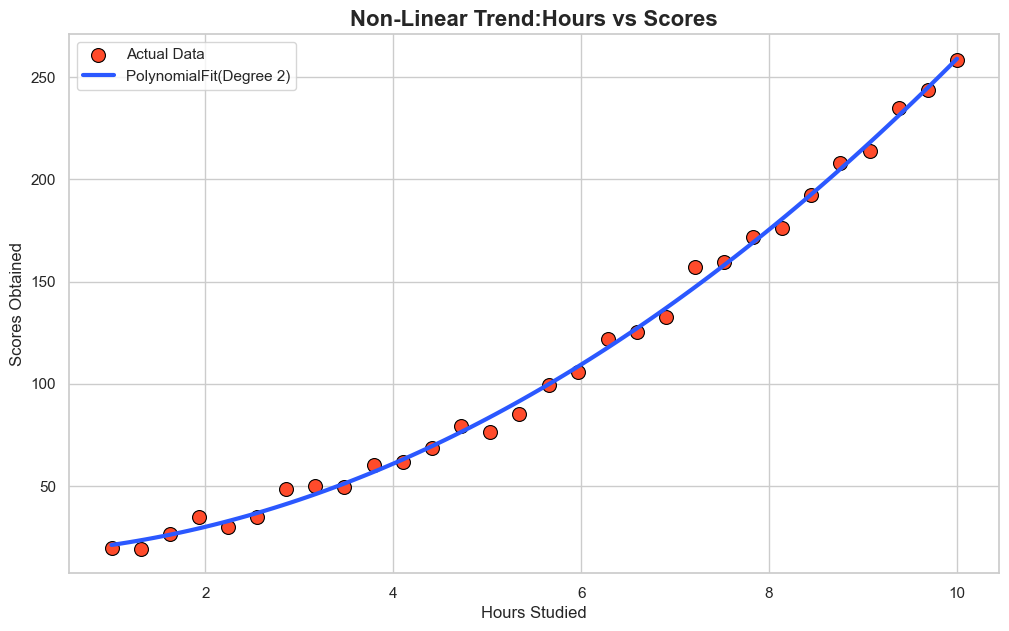

In [8]:
#Transform features to polynomial (Degree 2)
poly=PolynomialFeatures(degree=2)
X_poly=poly.fit_transform(X)

#Initialize and train the Linear Regression model
model=LinearRegression()
model.fit(X_poly,y)

print("Polynomial model trained successfully.")

# Visualize the data and the polynomial fit
py.figure(figsize=(12,7))

#Actual data points 
sns.scatterplot(x=df['Hours'],
                y=df['Scores'],color='#ff4b2b',
                s=100,label='Actual Data',edgecolor='black')
#Generate points fot the smooth curve
X_range=np.linspace(X.min(),X.max(),100).reshape(-1,1)
X_range_poly=poly.transform(X_range)
y_poly_pred=model.predict(X_range_poly)
py.plot(X_range,y_poly_pred,color='#2b58ff',linewidth=3,label='PolynomialFit(Degree 2)')

py.title('Non-Linear Trend:Hours vs Scores', fontsize=16,fontweight='bold')
py.xlabel('Hours Studied',fontsize=12)
py.ylabel('Scores Obtained',fontsize=12)
py.legend()
py.show()

In [17]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

# Example dataset (replace with your own data)
X = np.array([[1], [2], [3], [4], [5], [6], [7], [8], [9], [10]])
y = np.array([2, 4, 5, 4, 5, 7, 8, 9, 10, 12])

# Create polynomial features
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

# Train model
model = LinearRegression()
model.fit(X_poly, y)

# Predictions
y_pred = model.predict(X_poly)

# Metrics
mse = mean_squared_error(y, y_pred)
r2 = r2_score(y, y_pred)

print(f"Overall R² Score: {r2:.4f}")
print(f"Mean Squared Error: {mse:.2f}")

# Custom Prediction Function
def predict_score(hours):
    hours = float(hours)  # ensure numeric
    hours_poly = poly.transform([[hours]])
    prediction = model.predict(hours_poly)[0]
    
    print(f"\nPrediction for {hours} hours of study:")
    print(f"Estimated Score: {prediction:.2f}")

# User input
try:
    user_hours = float(input("Enter hours studied: "))
    predict_score(user_hours)
except ValueError:
    print("Invalid input! Please enter a numeric value.")

Overall R² Score: 0.9614
Mean Squared Error: 0.34



Prediction for 2.0 hours of study:
Estimated Score: 3.29
